In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [3]:
# Define path names and load some basic functions for reading in files

# Define the location of the file to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # modify if needed
experiment = "03182024_IF-FISH_test2" # this will be changed for each experiment

# Read in the experimental groups reference file
exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [11]:
# CHUNK 1 # 
# Load segmentation masks for images in one experiment

# This dictionary defines the folder inside of "experiment" that contains masks
file_folders = {
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# These dictionaries will store all mask files, their file names and the base name:
all_images = {"mask_n": []}
file_names = {"mask_n": []}
base_names = {"mask_n": []}  # Store base names for images and masks
errors = []  # List to store error messages

# Load files with parallel processing using img_loadr() from load_files.py
with ThreadPoolExecutor(max_workers=4) as executor:  # Adjust the number of workers as needed
    for f in file_folders:
        # Build the path to the folders indicated at the top
        file_path = os.path.join(parent_directory, experiment, file_folders[f])
        files = glob.glob(os.path.join(file_path, "*.tif"))
        # Run load_image() over the list of files in the folder (files, just above)
        results = executor.map(img_loadr, files)

        for result in results:
            # Unpack the tuples in results, and save the image in all_images[] 
            # and the file names in file_names[]
            image, filename = result
            if image is not None:
                all_images[f].append(image)
                file_names[f].append(filename)
                base_names[f].append(extract_base_name(filename))  # Store the base name

# Log the completion of image processing
if errors:
    logging.error(f"Completed with errors in {len(errors)} files.")
else:
    logging.info("All images and masks have been processed successfully without errors.")

# Optional: Summary of processed files
logging.info(f"Processed {len(file_names['mask_n'])} nuclei masks.")

# Now, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 
# all_images["mask_b"] contains all the background masks

2024-10-17 10:30:25,968 - INFO - All images and masks have been processed successfully without errors.
2024-10-17 10:30:25,968 - INFO - Processed 12 nuclei masks.


In [13]:
# CHUNK 2 #
# Load spot files for each image into a dictionary

spot_files = {"spots": []}
spot_file_names = {"spots": []} # Store the file names
spot_base_names = {"spots": []}  # Store base names 
spot_channels = [] # Store the channel information
spot_errors = []  # Store any errors

# Define the folder containing the spot files (assuming they are in the same experiment folder)
spots_folder = "spotiflow_results/"
spots_path = os.path.join(parent_directory, experiment, spots_folder)

# List all CSV files in the directory
csv_files = glob.glob(os.path.join(spots_path, "*.csv"))

# Read each CSV file and store the data and filename in the dictionary
for file in csv_files:
    try:
        spots = pd.read_csv(file)  # Assumes a simple CSV structure; modify if necessary
        file_name = os.path.basename(file)

        # Extract the channel from the file name (e.g., C1, C2, etc.)
        # Assumes file name starts with C followed by a number (such as "C1-", "C2-", etc)
        channel = int(file_name.split('-')[0][1])  # Get the number after 'C'
        
        spot_files['spots'].append(spots)
        spot_file_names['spots'].append(file_name)  # Save the filename
        spot_base_names['spots'].append(extract_base_name(file_name))  # Store the base name
        spot_channels.append(channel)  # Save the channel
        
    except Exception as e:
        spot_errors.append(file)
        logging.error(f"Error reading {file}: {str(e)}")

# Log completion
if spot_errors:
    logging.error(f"Completed with errors in {len(spot_errors)} files.")
else:
    logging.info("All spot files have been loaded successfully.")

2024-10-17 10:30:27,902 - INFO - All spot files have been loaded successfully.


In [15]:
# CHUNK 3 #
# Match spot files to nuclear mask files using the base_names common to all files

# Convert list of spot base names to a dictionary for faster lookup
spot_name_to_index = {base_name: idx for idx, base_name in enumerate(spot_base_names['spots'])}

# Match each nuclear mask with its corresponding spot file
matched_indices_with_spots = []
missing_spots = 0

for mask_index, mask_base_name in enumerate(base_names['mask_n']):
    spot_index = spot_name_to_index.get(mask_base_name)  # Use base names to match
    
    if spot_index is not None:
        matched_indices_with_spots.append((mask_index, spot_index))
    else:
        missing_spots += 1
        logging.warning(f"No matching spot file found for mask: {file_names['mask_n'][mask_index]}")

# Log the results of the matching
logging.info(f"Matched {len(matched_indices_with_spots)} nuclear masks with spot files. Missing spot files for {missing_spots} masks.")

2024-10-17 10:30:30,546 - INFO - Matched 12 nuclear masks with spot files. Missing spot files for 0 masks.


In [17]:
# Print a sample of matched pairs to verify correct matching
print("Sample of matched mask and spot file indices:")
for mask_index, spot_index in matched_indices_with_spots[:5]:  # Print first 5 matches
    print(f"Mask: {file_names['mask_n'][mask_index]} | Spot: {spot_file_names['spots'][spot_index]}")

Sample of matched mask and spot file indices:
Mask: C1-03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP_cp_masks.tif | Spot: C3-03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP.csv
Mask: C1-03182024_IF-FISH_fullFinn_2_MMStack_Pos3_MIP_cp_masks.tif | Spot: C3-03182024_IF-FISH_fullFinn_2_MMStack_Pos3_MIP.csv
Mask: C1-03182024_IF-FISH_fullFinn_1_MMStack_Pos0_MIP_cp_masks.tif | Spot: C3-03182024_IF-FISH_fullFinn_1_MMStack_Pos0_MIP.csv
Mask: C1-03182024_IF-FISH_fullFinn_3_MMStack_Pos3_MIP_cp_masks.tif | Spot: C3-03182024_IF-FISH_fullFinn_3_MMStack_Pos3_MIP.csv
Mask: C1-03182024_IF-FISH_fullFinn_1_MMStack_Pos1_MIP_cp_masks.tif | Spot: C3-03182024_IF-FISH_fullFinn_1_MMStack_Pos1_MIP.csv


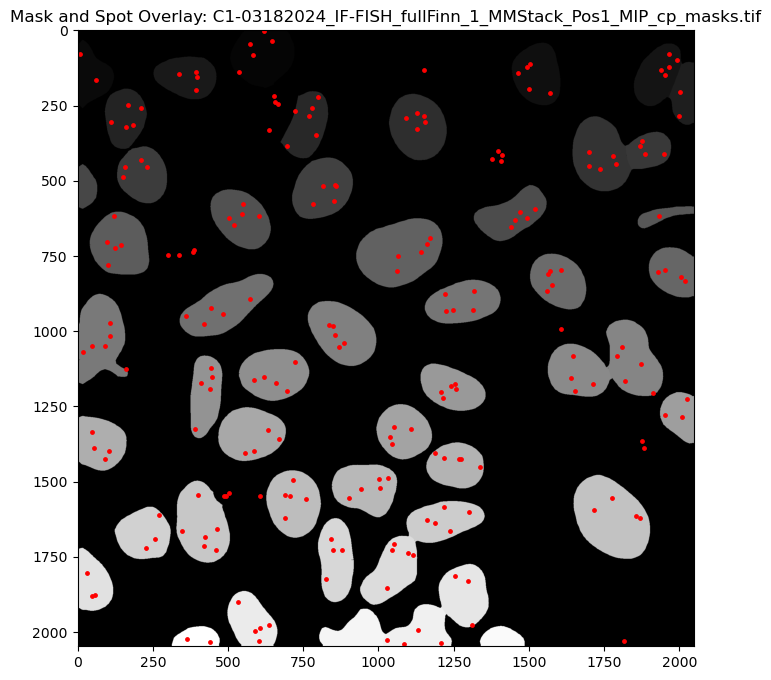

In [29]:
# Overlay a mask and its spot coordinates for visual confirmation that
# a) match was correct
# b) XY axes align on both images

# Pick an image index (1 - (n images -1))
i = 4

# Choose a matched mask and spot pair to plot
mask_index, spot_index = matched_indices_with_spots[i]  # i being the index picked above
mask = all_images['mask_n'][mask_index]
spots = spot_files['spots'][spot_index]

# The spot files have 'x' and 'y' as labels for columns containing coordinates
x_coords = spots['x']
y_coords = spots['y']

# Plot the mask
plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap='gray')
plt.scatter(x_coords, y_coords, 
            color = 'red', s = 6)  # Overlay spots in red
plt.title(f"Mask and Spot Overlay: {file_names['mask_n'][mask_index]}")
plt.show()

In [77]:
# CHUNK 4 (updated using base_names) #
# Assign each spot to a nuclear mask ROI based on their coordinates

# Generate a dictionary to hold the number of spots per ROI
spot_counts_per_roi = {}

# Iterate through the matched indices and corresponding base names
for mask_base_name, (mask_index, spot_index) in zip(base_names['mask_n'], matched_indices_with_spots):
    my_mask = all_images['mask_n'][mask_index]
    spot_coords = spot_files['spots'][spot_index]
    channel = spot_channels[spot_index]  # Get the channel for the current spot file

    x_coords = np.round(spot_coords['x']).values.astype(int)  # Convert to int for indexing
    y_coords = np.round(spot_coords['y']).values.astype(int)

    for x, y in zip(x_coords, y_coords):
        # Ensure the spot's coordinates are within the mask's bounds
        if 0 <= y < my_mask.shape[0] and 0 <= x < my_mask.shape[1]:
            roi_value = my_mask[y, x]  # The value in the mask at the spot's location
            if roi_value != 0:  # Skip background
                key = (mask_base_name, roi_value, channel)  # Now, the key includes the channel
                if key not in spot_counts_per_roi:
                    spot_counts_per_roi[key] = 0
                spot_counts_per_roi[key] += 1

In [79]:
# Convert the dictionary to a Pandas data frame

# Initialize a list to store the data for the DataFrame
spot_data = []

# Iterate through the spot_counts_per_roi dictionary
for (mask_base_name, roi_value, channel), spot_count in spot_counts_per_roi.items():
    spot_data.append({
        'base_name': mask_base_name,  # Base name of the mask/spot file
        'ROI': roi_value,             # ROI value
        'channel': channel,           # Channel number
        'spot_count': spot_count      # Number of spots in this ROI for the specific channel
    })

# Create a DataFrame from the collected data
spot_df = pd.DataFrame(spot_data)

# Display a sample of the data frame
print(spot_df.head(10))  

                                      base_name  ROI  channel  spot_count
0  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   47        3           5
1  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   45        3           5
2  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   46        3           4
3  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   44        3           4
4  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   41        3           5
5  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   43        3           5
6  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   42        3           6
7  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   38        3           5
8  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   37        3           5
9  03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP   40        3           5


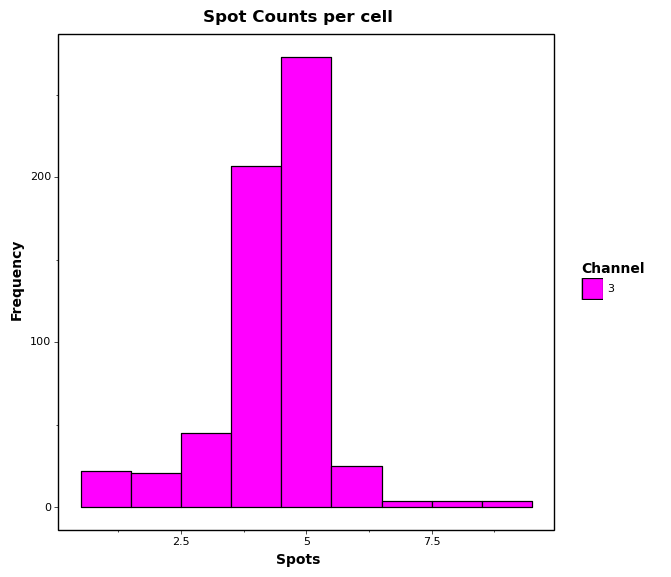

In [107]:
# Plot the number of spots found for all ROIs in all images

# Define a dictionary of channel colors
channel_colors = {1: 'blue', 2: 'springgreen', 3: 'magenta'}

# Define the plot
spot_histogram = (
    p9.ggplot(spot_df, p9.aes(x = 'spot_count', fill = 'factor(channel)')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black') +  # Create the histogram
    p9.labs(title = 'Spot Counts per cell', 
            x = 'Spots', y = 'Frequency', fill = "Channel") +  # Add labels
    p9.scale_fill_manual(values = channel_colors) +
    # p9.facet_wrap(' ~ base_name') +
    p9.theme_bw() + 
    p9.theme(aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'),
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Display the plot
print(spot_histogram)